In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

### 1. Importation des librairies

Importe les librairies nécessaires pour le projet, incluant `numpy`, `pandas`, `torch`, `torch.nn`, `torch.optim`, et `sklearn`.

In [ ]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Forme de X :", X.shape)
print("Forme de y :", y.shape)
print("Classes :", data.target_names)
print("Nombre de variables :", len(data.feature_names))

Forme de X : (569, 30)
Forme de y : (569,)
Classes : ['malignant' 'benign']
Nombre de variables : 30


### 2. Chargement du jeu de données Breast Cancer

Charge le jeu de données Breast Cancer de `sklearn.datasets` et affiche les formes des données, les classes et le nombre de variables.

In [ ]:
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y

print(df.head())
print(df.info())
print(df.describe())
print(df["target"].value_counts())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

### 3. Exploration préliminaire des données

Convertit les données en DataFrame Pandas et affiche les premières lignes, les informations, les statistiques descriptives et la distribution des classes cibles.

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train :", X_train.shape)
print("Validation :", X_val.shape)
print("Test :", X_test.shape)

Train : (398, 30)
Validation : (85, 30)
Test : (86, 30)


### 4. Division des données en ensembles d'entraînement, de validation et de test

Divise le jeu de données en ensembles d'entraînement, de validation et de test de manière stratifiée.

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

### 5. Standardisation des caractéristiques

Standardise les caractéristiques `X` avec `StandardScaler` pour améliorer la convergence et la performance du modèle.

In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

### 6. Conversion des données en Tensors PyTorch

Convertit les ensembles de données `numpy` en `torch.Tensor` pour l'entraînement PyTorch.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

Device utilisé : cpu


### 7. Définition du périphérique d'entraînement

Détecte et utilise le GPU (CUDA) si disponible, sinon le CPU, pour l'entraînement.

In [ ]:
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)

X_val_tensor = X_val_tensor.to(device)
y_val_tensor = y_val_tensor.to(device)

X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

### 8. Transfert des Tensors vers le périphérique

Transfère les Tensors PyTorch vers le périphérique sélectionné (GPU ou CPU).

In [ ]:
input_size = X_train.shape[1]
hidden_size = 64
output_size = 2

mlp_sequential = nn.Sequential(
    nn.Linear(input_size, hidden_size),
    nn.ReLU(),
    nn.Linear(hidden_size, 32),
    nn.ReLU(),
    nn.Linear(32, output_size)
).to(device)

print(mlp_sequential)

Sequential(
  (0): Linear(in_features=30, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=2, bias=True)
)


### 9. Définition d'un MLP avec `nn.Sequential`

Définit un Perceptron Multi-Couches (MLP) avec `torch.nn.Sequential` et le transfère au périphérique.

In [ ]:
class MLPClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLPClassifier, self).__init__()

        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 32)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(32, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

### 10. Définition d'un MLP personnalisé avec `nn.Module`

Définit une classe `MLPClassifier` personnalisée héritant de `torch.nn.Module` pour une architecture flexible.

In [ ]:
mlp_custom = MLPClassifier(input_size, hidden_size, output_size).to(device)

print(mlp_custom)

MLPClassifier(
  (fc1): Linear(in_features=30, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=2, bias=True)
)


### 11. Instanciation du MLP personnalisé

Instancie le modèle `MLPClassifier` personnalisé et affiche son architecture.

In [ ]:
for name, param in mlp_custom.named_parameters():
    print(name, param.shape)

fc1.weight torch.Size([64, 30])
fc1.bias torch.Size([64])
fc2.weight torch.Size([32, 64])
fc2.bias torch.Size([32])
fc3.weight torch.Size([2, 32])
fc3.bias torch.Size([2])


### 12. Inspection des paramètres du modèle (`named_parameters()`)

Affiche les noms et les formes des paramètres apprenables du modèle.

In [ ]:
state = mlp_custom.state_dict()

for key in state:
    print(key, state[key].shape)

fc1.weight torch.Size([64, 30])
fc1.bias torch.Size([64])
fc2.weight torch.Size([32, 64])
fc2.bias torch.Size([32])
fc3.weight torch.Size([2, 32])
fc3.bias torch.Size([2])


### 13. Inspection de l'état du modèle (`state_dict()`)

Affiche les clés et les formes des tenseurs stockés dans le `state_dict` du modèle.

In [ ]:
def train_model(model, X_train, y_train, X_val, y_val, epochs=100, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    val_accuracies = []

    best_val_acc = 0.0
    best_model_state = None

    for epoch in range(epochs):
        model.train()

        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val)
            val_losses.append(val_loss.item())

            _, val_preds = torch.max(val_outputs, 1)
            val_acc = (val_preds == y_val).float().mean().item()
            val_accuracies.append(val_acc)

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model_state = model.state_dict()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] - Loss: {loss.item():.4f} - Val Acc: {val_acc:.4f}")

    return train_losses, val_losses, val_accuracies, best_model_state, best_val_acc

### 14. Fonction d'entraînement du modèle

Encapsule l'entraînement et l'évaluation, utilisant `CrossEntropyLoss` et `Adam`, et suit la meilleure accuracy de validation.

In [ ]:
train_losses, val_losses, val_accuracies, best_model_state, best_val_acc = train_model(
    mlp_custom,
    X_train_tensor,
    y_train_tensor,
    X_val_tensor,
    y_val_tensor,
    epochs=100,
    lr=0.001
)

print("Meilleure accuracy validation :", best_val_acc)

Epoch [10/100] - Loss: 0.5323 - Val Acc: 0.8235
Epoch [20/100] - Loss: 0.3681 - Val Acc: 0.8941
Epoch [30/100] - Loss: 0.2327 - Val Acc: 0.9529
Epoch [40/100] - Loss: 0.1468 - Val Acc: 0.9882
Epoch [50/100] - Loss: 0.1030 - Val Acc: 0.9882
Epoch [60/100] - Loss: 0.0809 - Val Acc: 0.9765
Epoch [70/100] - Loss: 0.0681 - Val Acc: 0.9765
Epoch [80/100] - Loss: 0.0596 - Val Acc: 0.9765
Epoch [90/100] - Loss: 0.0534 - Val Acc: 0.9765
Epoch [100/100] - Loss: 0.0483 - Val Acc: 0.9765
Meilleure accuracy validation : 0.9882352948188782


### 15. Entraînement du modèle avec initialisation par défaut

Entraîne le modèle `mlp_custom` avec les paramètres par défaut et affiche la meilleure accuracy de validation.

In [ ]:
def init_gaussian(model):
    for layer in model.modules():
        if isinstance(layer, nn.Linear):
            nn.init.normal_(layer.weight, mean=0.0, std=0.01)
            nn.init.zeros_(layer.bias)

### 16. Fonction d'initialisation des poids Gaussienne

Initialise les poids des couches linéaires avec une distribution normale (Gaussienne) et les biais à zéro.

In [ ]:
def init_constant(model):
    for layer in model.modules():
        if isinstance(layer, nn.Linear):
            nn.init.constant_(layer.weight, 0.5)
            nn.init.zeros_(layer.bias)

### 17. Fonction d'initialisation des poids Constante

Initialise les poids des couches linéaires à 0.5 et les biais à zéro.

In [ ]:
def init_xavier(model):
    for layer in model.modules():
        if isinstance(layer, nn.Linear):
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)

### 18. Fonction d'initialisation des poids Xavier/Glorot

Utilise l'initialisation Xavier (uniforme) pour maintenir une variance constante des activations et gradients.

In [ ]:
initializations = {
    "Gaussienne": init_gaussian,
    "Constante": init_constant,
    "Xavier": init_xavier
}

results = {}

for init_name, init_function in initializations.items():
    print("\nInitialisation :", init_name)

    model = MLPClassifier(input_size, hidden_size, output_size).to(device)
    init_function(model)

    train_losses, val_losses, val_accuracies, best_state, best_acc = train_model(
        model,
        X_train_tensor,
        y_train_tensor,
        X_val_tensor,
        y_val_tensor,
        epochs=100,
        lr=0.001
    )

    results[init_name] = {
        "best_val_acc": best_acc,
        "best_state": best_state,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accuracies": val_accuracies
    }

print(results)


Initialisation : Gaussienne
Epoch [10/100] - Loss: 0.6844 - Val Acc: 0.6588
Epoch [20/100] - Loss: 0.6365 - Val Acc: 0.9647
Epoch [30/100] - Loss: 0.4998 - Val Acc: 0.9529
Epoch [40/100] - Loss: 0.3010 - Val Acc: 0.9647
Epoch [50/100] - Loss: 0.1707 - Val Acc: 0.9647
Epoch [60/100] - Loss: 0.1155 - Val Acc: 0.9882
Epoch [70/100] - Loss: 0.0895 - Val Acc: 0.9882
Epoch [80/100] - Loss: 0.0759 - Val Acc: 0.9882
Epoch [90/100] - Loss: 0.0664 - Val Acc: 0.9765
Epoch [100/100] - Loss: 0.0593 - Val Acc: 0.9765

Initialisation : Constante
Epoch [10/100] - Loss: 0.9702 - Val Acc: 0.9059
Epoch [20/100] - Loss: 0.6150 - Val Acc: 0.9059
Epoch [30/100] - Loss: 0.7354 - Val Acc: 0.9059
Epoch [40/100] - Loss: 0.6286 - Val Acc: 0.9059
Epoch [50/100] - Loss: 0.5455 - Val Acc: 0.9176
Epoch [60/100] - Loss: 0.5431 - Val Acc: 0.9176
Epoch [70/100] - Loss: 0.5394 - Val Acc: 0.9176
Epoch [80/100] - Loss: 0.5305 - Val Acc: 0.9176
Epoch [90/100] - Loss: 0.5246 - Val Acc: 0.9176
Epoch [100/100] - Loss: 0.5192

### 19. Comparaison des méthodes d'initialisation des poids

Compare la performance du modèle en entraînant un nouveau modèle pour chaque méthode d'initialisation (Gaussienne, Constante, Xavier).

In [ ]:
best_init = max(results, key=lambda name: results[name]["best_val_acc"])

print("Meilleure initialisation :", best_init)
print("Accuracy validation :", results[best_init]["best_val_acc"])

Meilleure initialisation : Gaussienne
Accuracy validation : 0.9882352948188782


### 20. Détermination de la meilleure initialisation

Identifie et affiche la méthode d'initialisation ayant donné la meilleure accuracy de validation.

In [ ]:
best_model = MLPClassifier(input_size, hidden_size, output_size).to(device)
best_model.load_state_dict(results[best_init]["best_state"])

<All keys matched successfully>

### 21. Chargement de l'état du meilleur modèle (Première exécution)

Charge les poids du meilleur modèle (selon la meilleure initialisation) pour l'évaluation.

In [ ]:
best_model = MLPClassifier(input_size, hidden_size, output_size).to(device)
best_model.load_state_dict(results[best_init]["best_state"])

<All keys matched successfully>

In [ ]:
torch.save(best_model.state_dict(), "best_mlp_model.pth")
print("Modèle sauvegardé.")

Modèle sauvegardé.


### 22. Sauvegarde du meilleur modèle

Sauvegarde le `state_dict` du meilleur modèle dans un fichier `.pth` pour persistance.

In [ ]:
loaded_model = MLPClassifier(input_size, hidden_size, output_size).to(device)
loaded_model.load_state_dict(torch.load("best_mlp_model.pth"))
loaded_model.eval()

print("Modèle rechargé avec succès.")

Modèle rechargé avec succès.


### 23. Chargement du modèle sauvegardé

Charge le modèle sauvegardé à partir du fichier `.pth` et le met en mode `eval()`.

In [ ]:
loaded_model.eval()

with torch.no_grad():
    test_outputs = loaded_model(X_test_tensor)
    _, test_preds = torch.max(test_outputs, 1)

y_test_np = y_test_tensor.cpu().numpy()
y_pred_np = test_preds.cpu().numpy()

accuracy = accuracy_score(y_test_np, y_pred_np)
precision = precision_score(y_test_np, y_pred_np)
recall = recall_score(y_test_np, y_pred_np)
f1 = f1_score(y_test_np, y_pred_np)
cm = confusion_matrix(y_test_np, y_pred_np)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1-score :", f1)
print("Matrice de confusion :")
print(cm)

print("\nRapport de classification :")
print(classification_report(y_test_np, y_pred_np, target_names=data.target_names))

Accuracy : 0.9767441860465116
Precision : 0.9814814814814815
Recall : 0.9814814814814815
F1-score : 0.9814814814814815
Matrice de confusion :
[[31  1]
 [ 1 53]]

Rapport de classification :
              precision    recall  f1-score   support

   malignant       0.97      0.97      0.97        32
      benign       0.98      0.98      0.98        54

    accuracy                           0.98        86
   macro avg       0.98      0.98      0.98        86
weighted avg       0.98      0.98      0.98        86



### 24. Évaluation du modèle sur l'ensemble de test

Évalue le modèle chargé sur l'ensemble de test et affiche les métriques de performance.

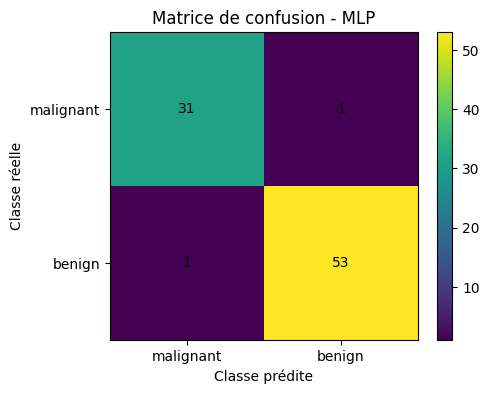

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Matrice de confusion - MLP")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.colorbar()

plt.xticks([0, 1], data.target_names)
plt.yticks([0, 1], data.target_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

### 25. Visualisation de la matrice de confusion

Visualise la matrice de confusion avec `matplotlib` pour analyser les erreurs de classification.

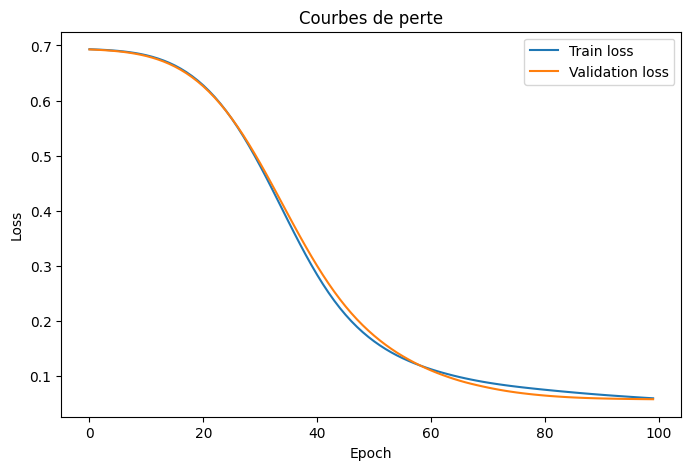

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(results[best_init]["train_losses"], label="Train loss")
plt.plot(results[best_init]["val_losses"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Courbes de perte")
plt.legend()
plt.show()

### 26. Visualisation des courbes de perte (entraînement et validation)

Trace les courbes de perte d'entraînement et de validation pour la meilleure initialisation, afin de visualiser la convergence et détecter le surapprentissage.